# Extracting Property Profiles from Paris Airbnb Reviews

**The problem statement:** A portfolio manager has properties across Paris and is getting mixed signals from guests. Some neighborhoods get great reviews, others get complaints, and it's hard to tell why just by reading thousands of reviews manually.

**What I built:** A pipeline that reads all guest reviews for a property listing and produces a structured "profile". Basically a short summary of what guests actually say about cleanliness, location, noise, host quality, value, and more. Think of it as having an analyst read every review and fill out a standardized scorecard.

**How it works (three steps):**
1. **Clean the reviews** — remove junk, cap how many reviews we send per listing (cost control)
2. **Ask an LLM** (Llama 3.3 70B via Groq) to extract a structured profile for a property listing from the reviews
3. **Check** whether the results are reliable, and estimate what it would cost at scale

**Data:** Inside Airbnb, Paris — 2.4M reviews across ~62K listings

**Model used:** Llama 3.3 70B via Groq (free tier, 30 RPM)

## Setup

For this problem, I will be using Llama 3.3 70B via Groq. The reason I picked this model over Gemini 2.5 flash is because it allows for more requests per minute and Gemini free-tier frequently ran into rate limit issues (429 Resource Exhausted).

**To get a free Groq API key:** Go to [console.groq.com](https://console.groq.com) → sign up → API Keys → Create API Key → paste below.

In [1]:
!pip install -q groq pandas matplotlib seaborn tqdm langdetect scikit-learn tiktoken

import warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 10.6 MB/s eta 0:00:00


In [3]:
# ── Configuration ──
GROQ_API_KEY = ""                       # Add your API key here
MAX_REVIEWS_PER_LISTING = 15            # How many reviews to send per property listing
MIN_REVIEW_LENGTH = 20                  # Ignore reviews shorter than this character length
SAMPLE_LISTINGS = 30                    # How many properties to process (Sample)
MODEL_NAME = "llama-3.3-70b-versatile"  # Free on Groq, strong reasoning model

assert GROQ_API_KEY, "Paste your Groq API key above first."
print("API key set.")

API key set.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, re, time, hashlib
from collections import Counter, defaultdict
from tqdm.notebook import tqdm
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("All imports ready.")

All imports ready.


## Getting the Data

I downloaded two files from Inside Airbnb:
- **reviews.csv.gz** — every guest review (our main dataset)
- **listings.csv.gz** — property details like neighbourhood, price, and Airbnb's own review scores (we'll use these later to check our work)

I picked the latest snapshot available for this data (16th June 2026).

In [5]:
import urllib.request

BASE = "https://data.insideairbnb.com/france/ile-de-france/paris"

DATE = "2026-06-16" # Latest snapshot date

def try_download(filename):
    url = f"{BASE}/{DATE}/data/{filename}"
    try:
        urllib.request.urlretrieve(url, filename)
        print(f"{filename} — {DATE} snapshot")
        return DATE
    except Exception:
        print(f"Could not find {filename}. Check insideairbnb.com/get-the-data for Paris.")
        return None

print("Downloading Paris data...")
try_download("reviews.csv.gz")
try_download("listings.csv.gz")

reviews.csv.gz — 2026-06-16 snapshot
listings.csv.gz — 2026-06-16 snapshot


'2026-06-16'

In [6]:
# Read the data into a Pandas Dataframe
# Pandas can automatically read .gz file, no need to uncompress them
reviews_raw = pd.read_csv("reviews.csv.gz", parse_dates=["date"])
listings = pd.read_csv("listings.csv.gz", low_memory=False)

# Check the size of these Dataframes
print(f"Reviews:  {len(reviews_raw):,} rows")
print(f"Listings: {len(listings):,} rows")
print(f"Date range: {reviews_raw['date'].min().date()} to {reviews_raw['date'].max().date()}")
print(f"Unique listings with reviews: {reviews_raw['listing_id'].nunique():,}")

Reviews:  2,404,369 rows
Listings: 77,679 rows
Date range: 2010-01-26 to 2026-06-28
Unique listings with reviews: 61,781


## Understanding the Data (Exploratory Data Analysis)

Let's look at what we're working with.

In [7]:
# A quick look at the raw data (reviews)
reviews_raw.head(3)

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,114543,66563271,2016-03-23,27034351,Renaud,"Tres bon accueil, apprtement agreable et tres ..."
1,114543,67236527,2016-03-27,30020827,Cindy,"Appartement impeccablement propre, spacieux où..."
2,114543,67688740,2016-03-30,10711075,Nassim,Très bel appartement. Fonctionnel et bien pla...


In [8]:
# Reading few actual reviews
samples = reviews_raw.dropna(subset=['comments']).sample(5, random_state=42)
for _, row in samples.iterrows():
    print(f"Listing {row['listing_id']} ({row['date'].date()}):")
    print(f'  "{str(row["comments"])[:200]}"\n')

Listing 7454540 (2016-01-03):
  "Accoglienza perfetta! Istruzioni esaustive e molto precise. La descrizione dell'appartamento è corrispondente, anzi dal vivo risulta essere più ampio di quanto previsto. Molto pulito e estremamente co"

Listing 23158726 (2024-06-29):
  "Messad was super friendly and responded quickly. She was also great when we needed a later check in. The place was also very nice and clean."

Listing 28467360 (2020-08-13):
  "Great little flat in an excellent location. Benjamin is really informative about the local area and communication was perfect! It was very hot (+37 degrees) when we stayed so the fans were much apprec"

Listing 12977655 (2025-04-27):
  "Our family of four was happy to have Valerie's apartment as a home base for our week in Paris. The location was phenomenal: close to Hotel Ville metro stop, great breakfast and food options right outs"

Listing 52256430 (2025-10-01):
  "Excelente localização e perto de tudo, o apartamento é exatamente como nas foto

### How many reviews does each property have?

This matters because we need to decide how many to send to the LLM. Some listings have thousands of reviews, so sending all of them would be slow and expensive.

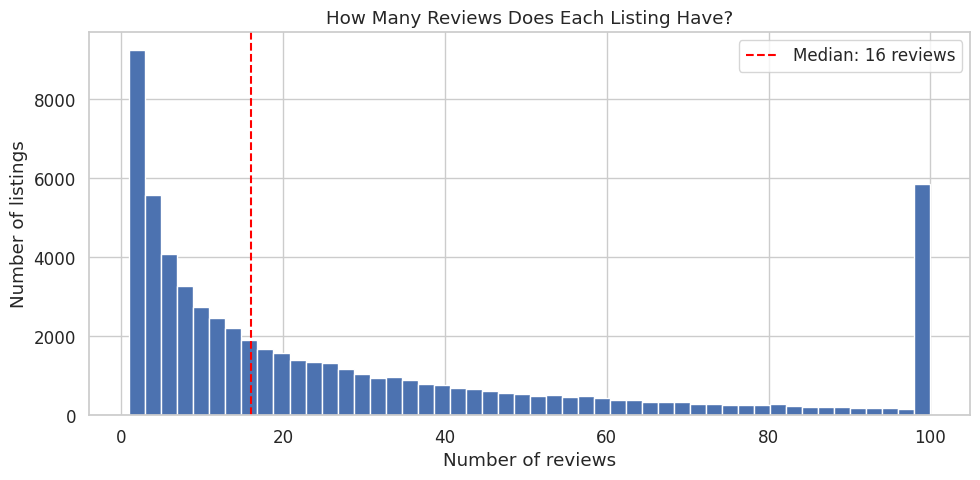

In [11]:
reviews_per_listing = reviews_raw.groupby("listing_id").size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(reviews_per_listing.clip(upper=100), bins=50, edgecolor='white', color='#4C72B0')
ax.axvline(reviews_per_listing.median(), color='red', linestyle='--',
           label=f'Median: {reviews_per_listing.median():.0f} reviews')
ax.set_xlabel("Number of reviews")
ax.set_ylabel("Number of listings")
ax.set_title("How Many Reviews Does Each Listing Have?")
ax.legend()
plt.tight_layout()
plt.show()

We can see that the graph is **heavily skewed**. Most listings have around 16 reviews, but 13,514 listings have 50+, and the max is 4,589.

So I'll be capping at 15 per listing to control costs.

### How long are the reviews?

Checking how long these reviews are in terms of character length (Capping at 1500 characters)

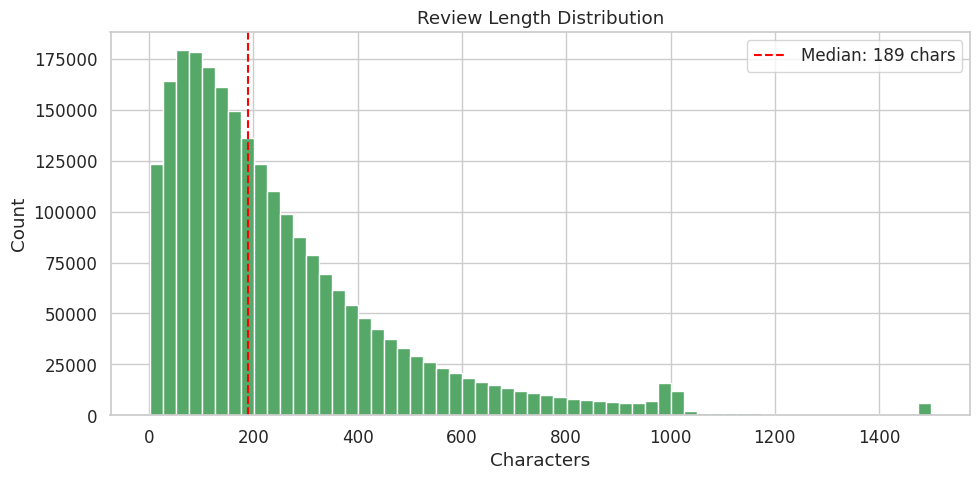

In [13]:
reviews_raw['comment_length'] = reviews_raw['comments'].astype(str).str.len()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(reviews_raw['comment_length'].clip(upper=1500), bins=60, edgecolor='white', color='#55A868')
ax.axvline(reviews_raw['comment_length'].median(), color='red', linestyle='--',
           label=f'Median: {reviews_raw["comment_length"].median():.0f} chars')
ax.set_xlabel("Characters")
ax.set_ylabel("Count")
ax.set_title("Review Length Distribution")
ax.legend()
plt.tight_layout()
plt.show()

Again we can see here that the graph is **heavily skewed**. Most reviews are short — around 189 characters (a couple of sentences) and Reviews under 20 chars (like 'Great!' or 'OK') are 92,891.

### What languages do guests write in?

Paris is international, so we need to check if we're dealing with just English or many languages.

We'll be using langdetect module to do this.

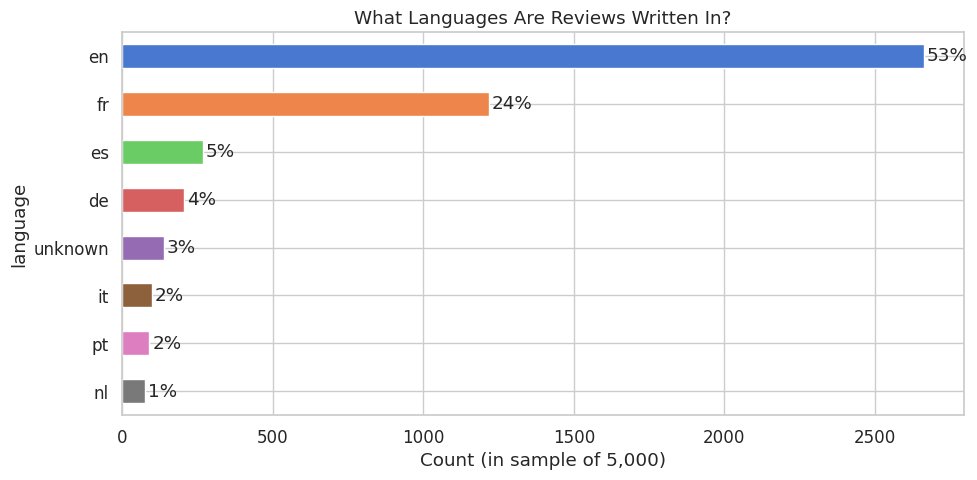

In [15]:
from langdetect import detect, LangDetectException

def safe_detect(text):
    try:
        if pd.isna(text) or len(str(text)) < 15:
            return 'unknown'
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

# Sample 5000 reviews (detecting all 2.4M would take too long)
lang_sample = reviews_raw.dropna(subset=['comments']).sample(
    min(5000, len(reviews_raw)), random_state=42
)
lang_sample['language'] = lang_sample['comments'].apply(safe_detect)
lang_counts = lang_sample['language'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(10, 5))
lang_counts.plot(kind='barh', ax=ax, color=sns.color_palette("muted", len(lang_counts)))
ax.set_xlabel("Count (in sample of 5,000)")
ax.set_title("What Languages Are Reviews Written In?")
ax.invert_yaxis()
for i, v in enumerate(lang_counts.values):
    ax.text(v + 10, i, f"{v/len(lang_sample):.0%}", va='center')
plt.tight_layout()
plt.show()

English + French make up about **77%** of reviews.

**Note**: The LLM we'll be using handles all these languages natively, so no need to translate them further.

## Component 1 — Cleaning the Reviews

Every word we send to the LLM costs tokens. A reasoning model also generates internal "thinking" tokens that grow with input length. So noisy input doesn't just increase cost, it can also confuse the model.

**What I chose to remove and why:**

| What | Why |
|---|---|
| Empty/blank reviews | Nothing to analyze so no use|
| Very short reviews (under 20 chars) | "Great!" and "OK" don't tell us anything specific |
| Airbnb auto-generated text | "The host canceled this reservation" isn't guest feedback |
| Extra whitespace, HTML tags | Wastes tokens without adding meaning |
| Near-duplicate reviews on the same listing | No point paying to read the same thing twice |
| Cap at 15 most recent reviews per listing | **This is the biggest cost saver** - We want to analyze the recent reviews, and review #50 rarely says anything new that #15 didn't |

I chose 15 reviews per listing to stay within the free-tier rate limits while keeping enough reviews for meaningful profiles. In production, this number could be higher, or replaced entirely with a token-based budget — instead of "keep 15 reviews," you'd say "keep adding reviews until you hit 4,000 tokens." That way short reviews let more through, and long detailed ones naturally use fewer slots.

**What I deliberately chose to keep:**
- **Non-English reviews** — the LLM reads French, Spanish, Chinese, etc. Filtering them would lose a huge chunk of guest feedback.
- **Emoji** — they carry sentiment ("❤️" vs "😡")
- **Similar reviews from different guests** — if 10 people say "noisy street," that's a pattern, not a duplicate.

In [16]:
def prepare_reviews(df, max_per_listing=MAX_REVIEWS_PER_LISTING,
                    min_length=MIN_REVIEW_LENGTH):
    stats = {'raw_count': len(df)}

    # Step 1: Drop nulls
    df = df.dropna(subset=['comments'])
    df = df[df['comments'].astype(str).str.strip().str.len() > 0].copy()
    stats['after_null_drop'] = len(df)

    # Step 2: Clean text (HTML, whitespace)
    def normalize(text):
        text = str(text)
        text = text.replace('&amp;', '&').replace('&lt;', '<').replace('&gt;', '>')
        text = text.replace('<br/>', ' ').replace('<br>', ' ')
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['comments_clean'] = df['comments'].apply(normalize)
    df['clean_length'] = df['comments_clean'].str.len()

    # Step 3: Drop very short reviews
    df = df[df['clean_length'] >= min_length].copy()
    stats['after_short_drop'] = len(df)

    # Step 4: Drop Airbnb boilerplate
    boilerplate = [
        r'^the host canceled', r'^this is an automated posting',
        r'^this listing has been', r'^no comments?\s*$',
        r'^n/a\s*$', r'^none\s*$',
    ]
    is_boilerplate = df['comments_clean'].str.lower().str.match(
        '|'.join(boilerplate), na=False
    )
    df = df[~is_boilerplate].copy()
    stats['after_boilerplate_drop'] = len(df)

    # Step 5: Remove near-duplicates within each listing
    def text_hash(text):
        normalized = re.sub(r'[^a-z0-9]', '', text.lower())[:100]
        return hashlib.md5(normalized.encode()).hexdigest()

    df['text_hash'] = df['comments_clean'].apply(text_hash)
    before_dedup = len(df)
    df = df.drop_duplicates(subset=['listing_id', 'text_hash']).copy()
    stats['duplicates_removed'] = before_dedup - len(df)
    stats['after_dedup'] = len(df)

    # Step 6: Cap reviews per listing (keep most recent)
    df = df.sort_values('date', ascending=False)
    df = df.groupby('listing_id').head(max_per_listing).copy()
    stats['after_cap'] = len(df)

    # Step 7: Truncate very long individual reviews (1500 chars ≈ 375 tokens)
    df['comments_clean'] = df['comments_clean'].str[:1500]

    stats['final_count'] = len(df)
    stats['final_listings'] = df['listing_id'].nunique()
    stats['avg_reviews_per_listing'] = len(df) / df['listing_id'].nunique()
    df = df.drop(columns=['text_hash'], errors='ignore')
    return df, stats

reviews_clean, prep_stats = prepare_reviews(reviews_raw.copy())

print("Pipeline results:")
print(f"  Started with:  {prep_stats['raw_count']:,} reviews")
print(f"  Ended with:    {prep_stats['final_count']:,} reviews ({prep_stats['final_listings']:,} listings)")
print(f"  Removed:       {prep_stats['raw_count'] - prep_stats['final_count']:,} reviews")
print(f"  Avg per listing: {prep_stats['avg_reviews_per_listing']:.1f} reviews")

Pipeline results:
  Started with:  2,404,369 reviews
  Ended with:    638,583 reviews (61,509 listings)
  Removed:       1,765,786 reviews
  Avg per listing: 10.4 reviews


### How much does cleaning actually save in tokens?

I use `tiktoken` here to count exact tokens rather than guessing. LLMs bill per token (roughly 4 characters each), so this tells us the real cost impact of cleaning.

We sample 10,000 reviews instead of all 2.4M because running tiktoken on the full dataset would take too long. We count tokens on the sample, then scale up proportionally to estimate the full dataset.

In [17]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")

# Total tokens before and after cleaning
total_raw_tokens = sum(len(enc.encode(str(t))) for t in
    reviews_raw['comments'].dropna().sample(10000, random_state=42))
total_clean_tokens = sum(len(enc.encode(t)) for t in
    reviews_clean['comments_clean'].sample(min(10000, len(reviews_clean)), random_state=42))

# Scale up to full dataset
raw_total = total_raw_tokens / 10000 * len(reviews_raw.dropna(subset=['comments']))
clean_total = total_clean_tokens / min(10000, len(reviews_clean)) * len(reviews_clean)

reduction_pct = (1 - clean_total / raw_total) * 100

print(f"Total tokens (estimated across full dataset):")
print(f"  Before cleaning: {raw_total:>14,.0f} tokens")
print(f"  After cleaning:  {clean_total:>14,.0f} tokens")
print(f"  Reduction:       {reduction_pct:.0f}%")
print(f"\nThis {reduction_pct:.0f}% reduction comes mostly from the cap at {MAX_REVIEWS_PER_LISTING} reviews per listing.")
print(f"Fewer reviews sent = fewer tokens = lower cost.")

Total tokens (estimated across full dataset):
  Before cleaning:    154,557,575 tokens
  After cleaning:      42,233,134 tokens
  Reduction:       73%

This 73% reduction comes mostly from the cap at 15 reviews per listing.
Fewer reviews sent = fewer tokens = lower cost.


### What did the cleaning change overall?

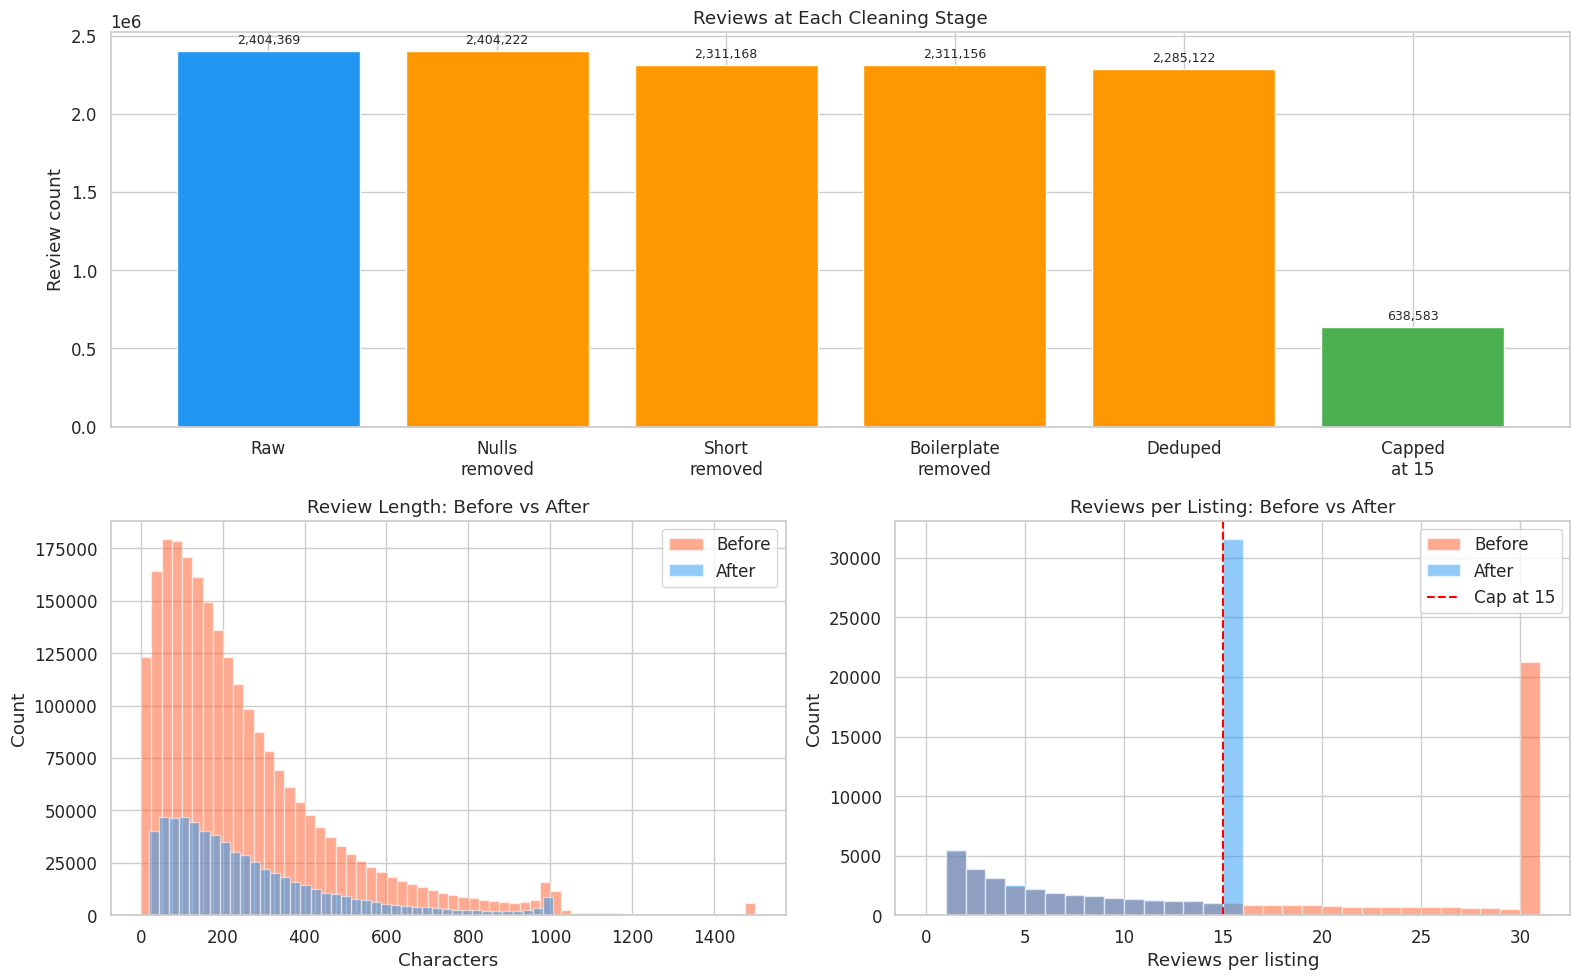

In [18]:
fig = plt.figure(figsize=(16, 10))

# Top: pipeline stages (full width)
ax1 = fig.add_subplot(2, 1, 1)
steps = ['Raw', 'Nulls\nremoved', 'Short\nremoved', 'Boilerplate\nremoved', 'Deduped', 'Capped\nat 15']
counts = [
    prep_stats['raw_count'], prep_stats['after_null_drop'],
    prep_stats['after_short_drop'], prep_stats['after_boilerplate_drop'],
    prep_stats['after_dedup'], prep_stats['after_cap'],
]
colors = ['#2196F3'] + ['#FF9800']*4 + ['#4CAF50']
ax1.bar(steps, counts, color=colors, edgecolor='white')
ax1.set_ylabel("Review count")
ax1.set_title("Reviews at Each Cleaning Stage")
for i, v in enumerate(counts):
    ax1.text(i, v + max(counts)*0.02, f'{v:,}', ha='center', fontsize=9)

# Bottom left: review length before vs after
ax2 = fig.add_subplot(2, 2, 3)
ax2.hist(reviews_raw['comment_length'].clip(upper=1500), bins=60,
         alpha=0.5, label='Before', color='#FF5722')
ax2.hist(reviews_clean['comments_clean'].str.len().clip(upper=1500), bins=60,
         alpha=0.5, label='After', color='#2196F3')
ax2.set_xlabel("Characters")
ax2.set_ylabel("Count")
ax2.set_title("Review Length: Before vs After")
ax2.legend()

# Bottom right: reviews per listing before vs after
ax3 = fig.add_subplot(2, 2, 4)
rpl_before = reviews_raw.groupby('listing_id').size()
rpl_after = reviews_clean.groupby('listing_id').size()
ax3.hist(rpl_before.clip(upper=30), bins=range(0, 32),
         alpha=0.5, label='Before', color='#FF5722')
ax3.hist(rpl_after.clip(upper=30), bins=range(0, 32),
         alpha=0.5, label='After', color='#2196F3')
ax3.axvline(MAX_REVIEWS_PER_LISTING, color='red', linestyle='--',
            label=f'Cap at {MAX_REVIEWS_PER_LISTING}')
ax3.set_xlabel("Reviews per listing")
ax3.set_ylabel("Count")
ax3.set_title("Reviews per Listing: Before vs After")
ax3.legend()

plt.tight_layout()
plt.show()

**Component 1 summary:** Started with 2.4M reviews, ended with 638K (72% reduction). The biggest decision was capping at 15 most recent reviews per listing — this accounted for 93% of what was removed. I chose recency over random sampling because the portfolio manager cares about the current guest experience, not what the property was like in 2019. The tradeoff: we might miss detailed older reviews in favor of shorter recent ones. In production, a token-based budget would be smarter than a fixed count.

## Component 2 — Prompt iteration and extracting Profiles with the LLM

### Prompt iteration

I went through several versions of the prompt before landing on the current one used below:

- **V1:** Simple instruction — "extract a profile from these reviews as JSON." The model returned inconsistent field names (sometimes "cleanliness", sometimes "hygiene") and sometimes made up information when reviews didn't mention a topic.
- **V2:** Added the explicit schema with required field names and enum values. This fixed the structure, but the model still guessed when evidence was thin (e.g. saying "positive" for noise when no review mentioned it).
- **V3 (current):** Added grounding rules ("use not_mentioned instead of guessing" and "base EVERY field on what reviews actually say"). Also added "think step by step" which improved the detail quality. This version produces consistent, grounded output.

Key decisions:
- `temperature=0.2` for consistency over creativity
- `response_format={"type": "json_object"}` to guarantee valid JSON
- Explicit schema in the prompt since Groq doesn't support schema enforcement like Gemini does


### What do I finally extract?

Each field was chosen to be useful to a portfolio manager — not just technically interesting.

| Field | What it tells us |
|---|---|
| **Overall sentiment** | Positive, mixed, or negative — quick triage |
| **Cleanliness** | The #1 complaint topic in hospitality |
| **Location** | Can't be changed — important for investment decisions |
| **Host communication** | Something the team can actually improve |
| **Check-in experience** | Common pain point, especially with self-check-in |
| **Noise level** | Neighbourhood issue — hard to fix, important to know |
| **Value for money** | Are guests feeling the price is fair? |
| **Top praises** | What's working — don't break it |
| **Top complaints** | What needs fixing — priority list |
| **Best guest fit** | Couples? Families? Solo travelers? → marketing decisions |
| **Confidence** | How sure is the model about its own answer? |

Each "signal" field uses a controlled set of values (positive / negative / not_mentioned) rather than free text, so we can filter and compare across properties in a spreadsheet.

### How does the prompt work?

The **system prompt** is the instructions — it stays the same for every listing. It tells the model who it is and what rules to follow (like "use not_mentioned instead of guessing").

The **user prompt** is the data — it changes for each listing. It's just the reviews.

Again, I used `temperature=0.2` (low randomness) because I want consistent, repeatable results — not creative writing.

In [19]:
# The schema tells the model exactly what JSON structure to return - (Structured output)
PROPERTY_PROFILE_SCHEMA = {
    "type": "object",
    "properties": {
        "overall_sentiment": {
            "type": "string",
            "enum": ["positive", "mixed", "negative"]
        },
        "cleanliness": {
            "type": "object",
            "properties": {
                "signal": {"type": "string", "enum": ["positive", "neutral", "negative", "not_mentioned"]},
                "detail": {"type": "string"}
            },
            "required": ["signal", "detail"]
        },
        "location_quality": {
            "type": "object",
            "properties": {
                "signal": {"type": "string", "enum": ["positive", "neutral", "negative", "not_mentioned"]},
                "detail": {"type": "string"}
            },
            "required": ["signal", "detail"]
        },
        "host_communication": {
            "type": "object",
            "properties": {
                "signal": {"type": "string", "enum": ["positive", "neutral", "negative", "not_mentioned"]},
                "detail": {"type": "string"}
            },
            "required": ["signal", "detail"]
        },
        "check_in_experience": {
            "type": "object",
            "properties": {
                "signal": {"type": "string", "enum": ["positive", "neutral", "negative", "not_mentioned"]},
                "detail": {"type": "string"}
            },
            "required": ["signal", "detail"]
        },
        "noise_level": {
            "type": "string",
            "enum": ["quiet", "moderate", "noisy", "not_mentioned"]
        },
        "value_perception": {
            "type": "object",
            "properties": {
                "signal": {"type": "string", "enum": ["positive", "neutral", "negative", "not_mentioned"]},
                "detail": {"type": "string"}
            },
            "required": ["signal", "detail"]
        },
        "top_praises": {"type": "array", "items": {"type": "string"}},
        "top_complaints": {"type": "array", "items": {"type": "string"}},
        "best_guest_fit": {
            "type": "array",
            "items": {
                "type": "string",
                "enum": ["couples", "families", "solo_travelers", "business_travelers", "groups"]
            }
        },
        "confidence": {
            "type": "string",
            "enum": ["high", "medium", "low"]
        }
    },
    "required": [
        "overall_sentiment", "cleanliness", "location_quality",
        "host_communication", "check_in_experience", "noise_level",
        "value_perception", "top_praises", "top_complaints",
        "best_guest_fit", "confidence"
    ]
}

print(f"Schema defined: {len(PROPERTY_PROFILE_SCHEMA['required'])} required fields")

Schema defined: 11 required fields


In [20]:
# System prompt: the instructions (same for every listing)
SYSTEM_PROMPT = """You are an expert hospitality analyst extracting structured property profiles from Airbnb guest reviews for a Paris portfolio manager.

Return a JSON object with these exact fields: overall_sentiment (positive/mixed/negative), cleanliness (object with signal and detail), location_quality (object with signal and detail), host_communication (object with signal and detail), check_in_experience (object with signal and detail), noise_level (quiet/moderate/noisy/not_mentioned), value_perception (object with signal and detail), top_praises (array of strings), top_complaints (array of strings), best_guest_fit (array from: couples/families/solo_travelers/business_travelers/groups), confidence (high/medium/low).

For signal fields use: positive, neutral, negative, or not_mentioned.

RULES:
1. Base EVERY field on what the reviews actually say. If reviews don't mention a topic, use "not_mentioned" — never guess.
2. "detail" fields should summarize what MULTIPLE reviewers said in 1-2 sentences.
3. "top_praises" and "top_complaints": list the 3-5 most frequently mentioned. Empty list is fine.
4. "confidence": "high" if 10+ reviews with clear signals, "medium" if 5-9 or mixed, "low" if <5 or vague.
5. Reviews are multilingual (French, English, etc). Extract insights from all of them.
6. "best_guest_fit": infer from review content. If unclear, use empty list.

Think step by step: read all reviews, assess each dimension, then synthesize."""

# User prompt: the data (changes for each listing)
def build_user_prompt(listing_id, reviews_text):
    return f"""Analyze these {len(reviews_text)} guest reviews for Airbnb listing {listing_id} in Paris.
Extract a structured property profile as JSON.

REVIEWS:
{chr(10).join(f'[Review {i+1}]: {r}' for i, r in enumerate(reviews_text))}"""

print(f"System prompt: {len(SYSTEM_PROMPT)} chars")

System prompt: 1444 chars


### Quick testing of V1 version of the prompt to show why prompt design matters

In [22]:
# Quick demonstration of why prompt design matters
# Pick 2 listings with 5+ reviews
test_ids = reviews_clean.groupby('listing_id').size()
test_ids = test_ids[test_ids >= 5].index[:2].tolist()

for test_id in test_ids:
    test_reviews = reviews_clean[reviews_clean['listing_id'] == test_id]['comments_clean'].tolist()[:15]

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "user", "content": f"Extract a property profile from these reviews as JSON:\n\n" +
             "\n".join(test_reviews)}
        ],
        response_format={"type": "json_object"},
        temperature=0.2,
        max_tokens=2048,
    )

    result = json.loads(response.choices[0].message.content)
    print(f"=== Listing {test_id} — top-level fields ===")
    print(f"  {list(result.keys())}")
    print()

=== Listing 3109 — top-level fields ===
  ['property_profile']

=== Listing 7397 — top-level fields ===
  ['location', 'apartment', 'host', 'neighborhood', 'accessibility']



We can see above that listing 3109 wrapped everything under one key 'property_profile', while Listing 7397 used 5 separate keys like 'location' and 'apartment'.

Same prompt, same model — completely different structures. Hence this shows our simple prompt (V1 version) won't work as it returns inconsistent JSON fields.

In [25]:
def extract_profile(listing_id, reviews_text, retries=2):
    """Send reviews to Groq (Llama 3.3 70B) and extract a structured profile."""
    user_prompt = build_user_prompt(listing_id, reviews_text)
    result = {
        'listing_id': listing_id, 'n_reviews': len(reviews_text),
        'profile': None, 'raw_response': None,
        'tokens_in': 0, 'tokens_out': 0,
        'latency_s': 0, 'success': False, 'error': None,
    }

    for attempt in range(retries + 1):
        try:
            start = time.time()
            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": user_prompt}
                ],
                response_format={"type": "json_object"},
                temperature=0.2,
                max_tokens=2048,
            )
            result['latency_s'] = time.time() - start
            result['raw_response'] = response.choices[0].message.content
            result['tokens_in'] = response.usage.prompt_tokens
            result['tokens_out'] = response.usage.completion_tokens

            # Parse JSON
            try:
                profile = json.loads(response.choices[0].message.content)
            except json.JSONDecodeError:
                match = re.search(r'```(?:json)?\s*({.*?})\s*```',
                                  response.choices[0].message.content, re.DOTALL)
                if match:
                    profile = json.loads(match.group(1))
                else:
                    raise ValueError("Could not parse JSON from response")

            result['profile'] = profile
            result['success'] = True
            return result
        except Exception as e:
            result['error'] = str(e)
            if attempt < retries:
                time.sleep(3)
    return result

print("Extraction function ready.")

Extraction function ready.


### Running the extraction

I send each listing's cleaned reviews to the LLM and collect the results. Groq's free tier allows 30 requests/minute — much more generous than Gemini's 10, so this runs relatively fast.

We sample 30 listings randomly to run this extraction. To get better results, we ensure none of these listings have less than 5 reviews.

In [26]:
# Select listings with at least 5 reviews
reviews_per = reviews_clean.groupby('listing_id').size()
eligible = reviews_per[reviews_per >= 5].index.tolist()
print(f"Listings with 5+ reviews: {len(eligible):,}")

np.random.seed(42)
sample_ids = np.random.choice(eligible, size=min(SAMPLE_LISTINGS, len(eligible)), replace=False)
grouped = reviews_clean[reviews_clean['listing_id'].isin(sample_ids)].groupby('listing_id')

# Run extraction
results = []
for listing_id in tqdm(sample_ids, desc="Extracting profiles"):
    if listing_id in grouped.groups:
        review_texts = grouped.get_group(listing_id)['comments_clean'].tolist()
    else:
        continue
    result = extract_profile(listing_id, review_texts)
    results.append(result)
    time.sleep(3)  # Groq allows 30 RPM

successful = [r for r in results if r['success']]
failed = [r for r in results if not r['success']]

print(f"\nDone: {len(successful)}/{len(results)} successful")
if failed:
    print(f"Failed: {len(failed)} (likely rate-limit errors)")

Listings with 5+ reviews: 46,491


Extracting profiles:   0%|          | 0/30 [00:00<?, ?it/s]


Done: 30/30 successful


In [27]:
# Retry failed extractions with a longer delay
if failed:
    failed_ids = [r['listing_id'] for r in failed]
    print(f"Retrying {len(failed_ids)} failed listings...\n")
    for listing_id in tqdm(failed_ids, desc="Retrying"):
        group = grouped.get_group(listing_id)
        review_texts = group['comments_clean'].tolist()
        result = extract_profile(listing_id, review_texts)
        results = [r for r in results if r['listing_id'] != listing_id]
        results.append(result)
        time.sleep(5)
    successful = [r for r in results if r['success']]
    print(f"After retry: {len(successful)}/{len(results)} successful")

### What do the extracted profiles look like?

Let's take a look at how our extracted profile looks like by printing the different fields

In [28]:
for r in results[:3]:
    if r['success']:
        p = r['profile']
        print(f"{'='*65}")
        print(f"Listing {r['listing_id']} | {r['n_reviews']} reviews | "
              f"{r['tokens_in']} in / {r['tokens_out']} out tokens | {r['latency_s']:.1f}s")
        print(f"  Sentiment:    {p.get('overall_sentiment')} (confidence: {p.get('confidence')})")
        print(f"  Cleanliness:  {p.get('cleanliness',{}).get('signal')} — {p.get('cleanliness',{}).get('detail','')}")
        print(f"  Location:     {p.get('location_quality',{}).get('signal')} — {p.get('location_quality',{}).get('detail','')}")
        print(f"  Host:         {p.get('host_communication',{}).get('signal')} — {p.get('host_communication',{}).get('detail','')}")
        print(f"  Check-in:     {p.get('check_in_experience',{}).get('signal')} — {p.get('check_in_experience',{}).get('detail','')}")
        print(f"  Noise:        {p.get('noise_level')}")
        print(f"  Value:        {p.get('value_perception',{}).get('signal')} — {p.get('value_perception',{}).get('detail','')}")
        print(f"  Praises:      {p.get('top_praises', [])}")
        print(f"  Complaints:   {p.get('top_complaints', [])}")
        print(f"  Guest fit:    {p.get('best_guest_fit', [])}")
        print()

Listing 763419 | 13 reviews | 1168 in / 357 out tokens | 1.3s
  Sentiment:    positive (confidence: high)
  Cleanliness:  positive — Multiple reviewers mentioned the apartment was clean and neat, with one reviewer noting it was 'clean and nice'.
  Location:     positive — Reviewers praised the location, mentioning its proximity to grocery stores, metro lines, and bus stops, making it easy to access various parts of Paris.
  Host:         positive — Aline was consistently described as helpful, attentive, and responsive, with reviewers appreciating her guidance, recommendations, and small gestures like welcome gifts.
  Check-in:     positive — Reviewers found the check-in process to be smooth, with Aline being flexible and accommodating, ensuring a pleasant start to their stay.
  Noise:        quiet
  Value:        positive — Guests generally felt they received good value for their stay, with one reviewer mentioning they 'highly recommend' the place and another appreciating the savings f

The profiles are pulling out specific, actionable details — not generic summaries. For example, listing 763419 correctly identifies the non-functional kitchen extractor hood and limited wifi as complaints, while praising the cleanliness and hospitality. These are the kinds of signals a property manager can actually act on.

**Plotting different graphs to analyze the extracted profiles**

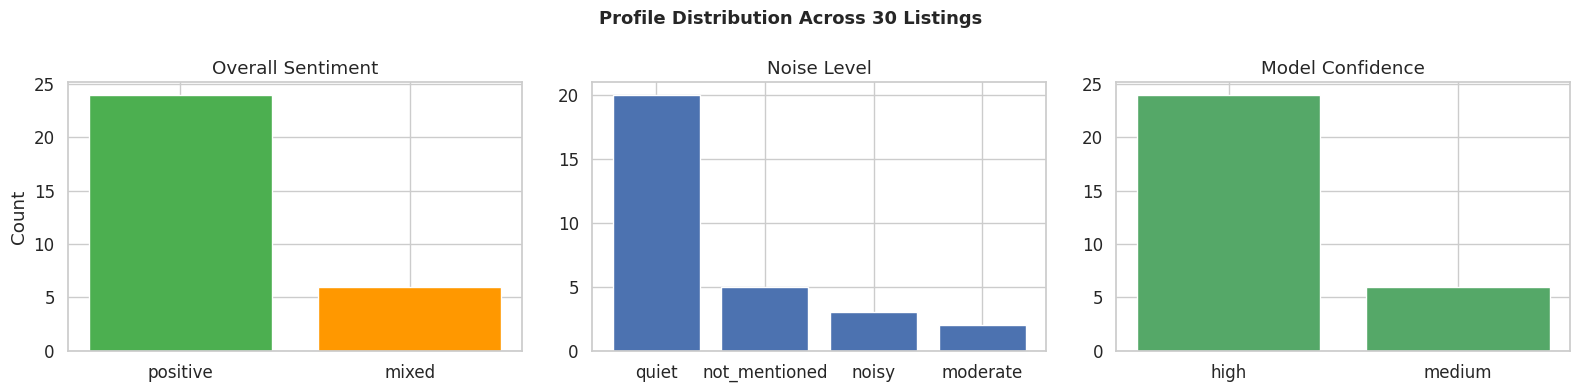

In [55]:
# How do the 30 extracted profiles break down?
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Sentiment distribution
sent = Counter(r['profile'].get('overall_sentiment') for r in successful)
axes[0].bar(sent.keys(), sent.values(), color=['#4CAF50','#FF9800','#F44336'][:len(sent)])
axes[0].set_title('Overall Sentiment')
axes[0].set_ylabel('Count')

# Noise levels
noise = Counter(
    r['profile'].get('noise_level') if isinstance(r['profile'].get('noise_level'), str)
    else r['profile'].get('noise_level', {}).get('signal', 'unknown')
    for r in successful
)
axes[1].bar(noise.keys(), noise.values(), color='#4C72B0')
axes[1].set_title('Noise Level')

# Confidence
conf = Counter(r['profile'].get('confidence') for r in successful)
axes[2].bar(conf.keys(), conf.values(), color='#55A868')
axes[2].set_title('Model Confidence')

plt.suptitle('Profile Distribution Across 30 Listings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

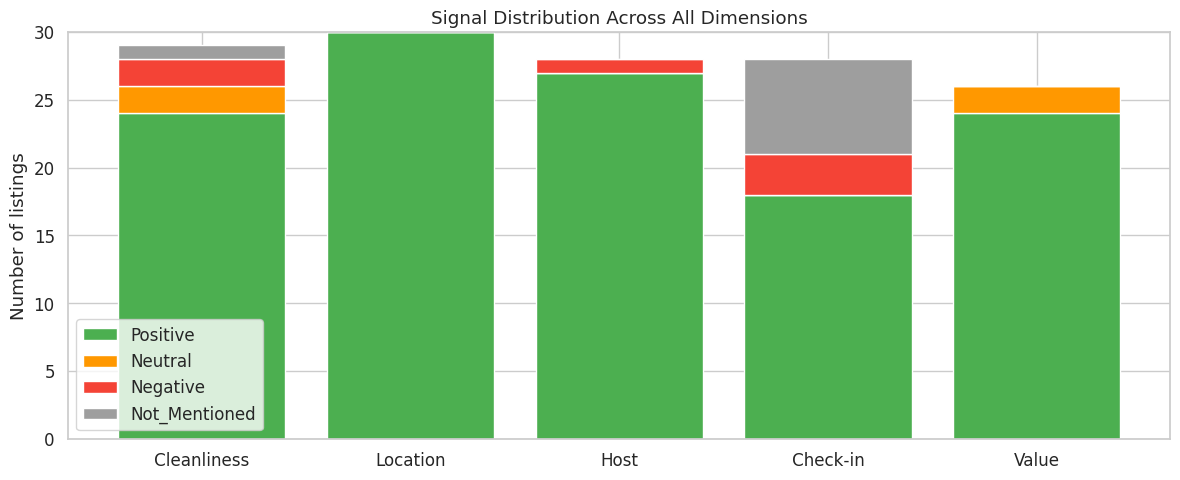

In [58]:
# How did each dimension score across all listings?
dimensions = ['cleanliness', 'location_quality', 'host_communication',
              'check_in_experience', 'value_perception']
dim_labels = ['Cleanliness', 'Location', 'Host', 'Check-in', 'Value']
signals = ['positive', 'neutral', 'negative', 'not_mentioned']
signal_colors = {'positive': '#4CAF50', 'neutral': '#FF9800', 'negative': '#F44336', 'not_mentioned': '#9E9E9E'}

data = {s: [] for s in signals}
for dim in dimensions:
    counts = Counter(r['profile'].get(dim, {}).get('signal', 'unknown') for r in successful)
    for s in signals:
        data[s].append(counts.get(s, 0))

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(dimensions))
for s in signals:
    ax.bar(dim_labels, data[s], bottom=bottom, label=s.title(), color=signal_colors[s])
    bottom += np.array(data[s])

ax.set_ylabel('Number of listings')
ax.set_title('Signal Distribution Across All Dimensions')
ax.legend()
plt.tight_layout()
plt.show()

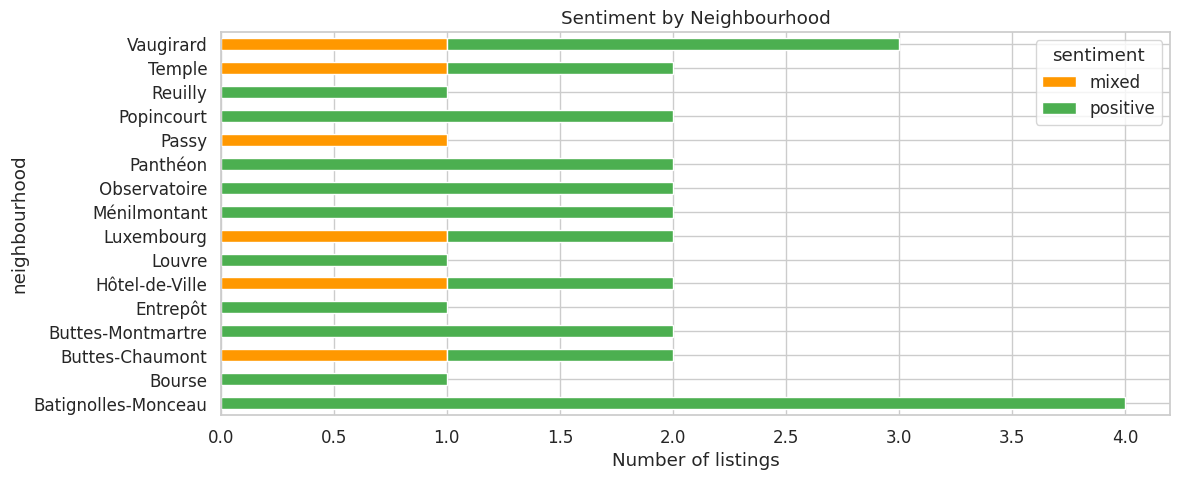

In [57]:
# Does sentiment vary by neighbourhood?
neighbourhood_data = []
for r in successful:
    lid = r['listing_id']
    row = listings[listings['id'] == lid]
    if not row.empty:
        neighbourhood_data.append({
            'neighbourhood': row.iloc[0].get('neighbourhood_cleansed', 'Unknown'),
            'sentiment': r['profile'].get('overall_sentiment'),
        })

if neighbourhood_data:
    nh_df = pd.DataFrame(neighbourhood_data)
    nh_counts = nh_df.groupby(['neighbourhood', 'sentiment']).size().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = {'positive': '#4CAF50', 'mixed': '#FF9800', 'negative': '#F44336'}
    nh_counts.plot(kind='barh', stacked=True, ax=ax,
                   color=[colors.get(c, '#999') for c in nh_counts.columns])
    ax.set_title('Sentiment by Neighbourhood')
    ax.set_xlabel('Number of listings')
    plt.tight_layout()
    plt.show()

**Why an LLM over classical NLP?**

Methods like TF-IDF or BERTopic count word frequency — they can't tell that "not clean" and "very clean" are opposites. For structured extraction from messy, multilingual reviews, we need a model that understands context and meaning, not just word counts.

**Component 2 summary:** The LLM extracted structured profiles for 30 listings with a 100% parse rate. Key design decisions: (1) enum values like "positive/negative/not_mentioned" instead of free text, so profiles can be compared across 10,000 listings in a spreadsheet; (2) "not_mentioned" as an explicit option — missing data is better than made-up data when a portfolio manager might act on it; (3) system/user prompt split to avoid repeating the schema 30 times, saving tokens.

## Component 3 — Is It Reliable? What Would It Cost?

### Checking the results

Now, the extracted profiles look good, but how reliable are they? To verify this, I used two different ways:

**A) Internal coherence** — does each profile make sense on its own? (e.g., if sentiment is "positive" but there are more complaints than praises, something is wrong) - This is more of a naive approach.

**B) Cross-validation against Airbnb's actual scores (from listings.csv)** — Airbnb already has guest ratings for cleanliness, location, communication, and value. If my pipeline says "cleanliness is positive," that listing's actual Airbnb score should be high too. This is real ground truth that the model never saw.

In [30]:
# A) Internal Coherence

coherence_issues = []
for r in successful:
    p = r['profile']
    issues = []
    n_praises = len(p.get('top_praises', []))
    n_complaints = len(p.get('top_complaints', []))

    if p.get('overall_sentiment') == 'positive' and n_complaints > n_praises:
        issues.append('Positive sentiment but more complaints than praises')
    if p.get('overall_sentiment') == 'negative' and n_praises > n_complaints:
        issues.append('Negative sentiment but more praises than complaints')
    if r['n_reviews'] >= 10 and p.get('confidence') == 'low':
        issues.append('Many reviews but low confidence')
    if r['n_reviews'] < 5 and p.get('confidence') == 'high':
        issues.append('Few reviews but high confidence')

    noise_in_complaints = any('noise' in c.lower() or 'noisy' in c.lower() or 'loud' in c.lower()
                              for c in p.get('top_complaints', []))
    if p.get('noise_level') == 'noisy' and not noise_in_complaints:
        issues.append('Marked noisy but noise not in complaints')
    if p.get('noise_level') == 'quiet' and noise_in_complaints:
        issues.append('Marked quiet but noise in complaints')

    coherence_issues.append({'listing_id': r['listing_id'], 'issues': issues})

coherent = sum(1 for c in coherence_issues if not c['issues'])
print(f"Internal coherence: {coherent}/{len(coherence_issues)} profiles are consistent")
if coherent < len(coherence_issues):
    print("\nIssues found:")
    for c in coherence_issues:
        if c['issues']:
            print(f"  Listing {c['listing_id']}: {c['issues']}")
else:
    print("No contradictions found — every profile is internally consistent.")

Internal coherence: 30/30 profiles are consistent
No contradictions found — every profile is internally consistent.


In [53]:
# ── B) Cross-Validation Against Airbnb's Own Scores ──

THRESHOLD = 4.0

val_rows = []
for r in successful:
    p = r['profile']
    lid = r['listing_id']
    row = listings[listings['id'] == lid]
    if row.empty:
        continue
    row = row.iloc[0]
    val_rows.append({
        'ext_cleanliness': p.get('cleanliness',{}).get('signal'),
        'ext_location': p.get('location_quality',{}).get('signal'),
        'ext_communication': p.get('host_communication',{}).get('signal'),
        'ext_value': p.get('value_perception',{}).get('signal'),
        'act_cleanliness': row.get('review_scores_cleanliness'),
        'act_location': row.get('review_scores_location'),
        'act_communication': row.get('review_scores_communication'),
        'act_value': row.get('review_scores_value'),
    })

val_df = pd.DataFrame(val_rows)

dims = [('Cleanliness','ext_cleanliness','act_cleanliness'),
        ('Location','ext_location','act_location'),
        ('Communication','ext_communication','act_communication'),
        ('Value','ext_value','act_value')]

# Accuracy per dimension
overall_correct = 0
overall_total = 0
for _, r in val_df.iterrows():
    for name, ec, ac in dims:
        if pd.notna(r.get(ec)) and pd.notna(r.get(ac)):
            if r[ec] == 'positive' and r[ac] >= THRESHOLD:
                overall_correct += 1; overall_total += 1
            elif r[ec] == 'negative' and r[ac] < THRESHOLD:
                overall_correct += 1; overall_total += 1
            elif r[ec] in ('positive', 'negative'):
                overall_total += 1

print(f"{'='*60}")
print(f"  Cross-Validation: Our Extraction vs Airbnb's Actual Scores")
print(f"{'='*60}")
print(f"\n  {'Dimension':<20} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print(f"  {'-'*50}")

for name, ec, ac in dims:
    sub = val_df[[ec, ac]].dropna()
    sub = sub[sub[ec].isin(['positive', 'negative'])]
    correct = 0
    for _, r in sub.iterrows():
        if r[ec] == 'positive' and r[ac] >= THRESHOLD:
            correct += 1
        elif r[ec] == 'negative' and r[ac] < THRESHOLD:
            correct += 1
    print(f"  {name:<20} {correct:>8} {len(sub):>8} {correct/len(sub):>9.0%}")

print(f"  {'-'*50}")
print(f"  {'Overall':<20} {overall_correct:>8} {overall_total:>8} {overall_correct/overall_total:>9.0%}")
print(f"{'='*60}")

  Cross-Validation: Our Extraction vs Airbnb's Actual Scores

  Dimension             Correct    Total   Accuracy
  --------------------------------------------------
  Cleanliness                24       26       92%
  Location                   30       30      100%
  Communication              27       28       96%
  Value                      24       24      100%
  --------------------------------------------------
  Overall                   105      108       97%


**Overall accuracy: 97%** (105 out of 108 predictions matched reality).

Location and value were perfect at 100%. Cleanliness and communication had 3 mismatches — in each case the model flagged a listing as "negative" but the actual Airbnb score was above 4.0. The reverse (saying "positive" when the score is low) didn't happen in this sample, but both types of errors are possible.

**Why the mismatch?** Text reviews and star ratings measure different things. A listing can have a 4.4 star rating while a few guests still complain about cleanliness in their written review. The model picks up those complaints correctly — they're real — but the overall star rating stays high because the majority of guests were happy. So the model isn't necessarily wrong, it's just more sensitive to negative signals than the aggregated score.

### What would scaling this pipeline to process 10,000 listings cost?

In [33]:
tokens_in = [r['tokens_in'] for r in successful]
tokens_out = [r['tokens_out'] for r in successful]
latencies = [r['latency_s'] for r in successful]

print(f"Token usage across {len(successful)} listings:")
print(f"{'='*50}")
print(f"  {'':20} {'Avg':>8}  {'Min':>8}  {'Max':>8}")
print(f"  {'-'*45}")
print(f"  {'Input tokens':<20} {np.mean(tokens_in):>8,.0f}  {np.min(tokens_in):>8,.0f}  {np.max(tokens_in):>8,.0f}")
print(f"  {'Output tokens':<20} {np.mean(tokens_out):>8,.0f}  {np.min(tokens_out):>8,.0f}  {np.max(tokens_out):>8,.0f}")
print(f"  {'Response time (s)':<20} {np.mean(latencies):>8.1f}  {np.min(latencies):>8.1f}  {np.max(latencies):>8.1f}")

Token usage across 30 listings:
                            Avg       Min       Max
  ---------------------------------------------
  Input tokens            1,256       620     2,033
  Output tokens             366       321       426
  Response time (s)         5.6       1.0      17.7


In [40]:
N = 10_000

# Llama 3.3 70B on Groq pricing (paid tier)
INPUT_PRICE = 0.59   # $ per million input tokens
OUTPUT_PRICE = 0.79   # $ per million output tokens

avg_in = np.mean(tokens_in)
avg_out = np.mean(tokens_out)
avg_time = np.mean(latencies)

total_in = avg_in * N
total_out = avg_out * N
input_cost = total_in / 1e6 * INPUT_PRICE
output_cost = total_out / 1e6 * OUTPUT_PRICE
total_api_cost = input_cost + output_cost

error_rate = 1 - len(successful)/len(results)

print(f"{'='*55}")
print(f"  SCALE PROJECTION: 10,000 LISTINGS")
print(f"{'='*55}")
print(f"\n  Based on our sample of {len(successful)} listings:\n")
print(f"  ── Tokens ──")
print(f"  Avg input tokens/listing:    {avg_in:>10,.0f}")
print(f"  Avg output tokens/listing:   {avg_out:>10,.0f}")
print(f"  Total input tokens (10K):    {total_in:>10,.0f}")
print(f"  Total output tokens (10K):   {total_out:>10,.0f}")
print(f"\n  ── API Cost ──")
print(f"  Input:   {total_in/1e6:.1f}M tokens × ${INPUT_PRICE}/M = ${input_cost:.2f}")
print(f"  Output:  {total_out/1e6:.1f}M tokens × ${OUTPUT_PRICE}/M = ${output_cost:.2f}")
print(f"  {'─'*40}")
print(f"  Total API cost:                  ${total_api_cost:.2f}")
print(f"\n  ── Time ──")
print(f"  Avg response time: {avg_time:.1f}s per listing")
print(f"  At 30 RPM: ~{N/30/60:.0f} hours")
print(f"  With 5 parallel workers: ~{N/30/60/5:.0f} hours")
if error_rate > 0:
    print(f"\n  ── Reliability ──")
    print(f"  Our {error_rate:.0%} failure rate was from free-tier limits.")
    print(f"  On the paid tier, this drops to near zero.")

  SCALE PROJECTION: 10,000 LISTINGS

  Based on our sample of 30 listings:

  ── Tokens ──
  Avg input tokens/listing:         1,256
  Avg output tokens/listing:          366
  Total input tokens (10K):    12,561,667
  Total output tokens (10K):    3,660,667

  ── API Cost ──
  Input:   12.6M tokens × $0.59/M = $7.41
  Output:  3.7M tokens × $0.79/M = $2.89
  ────────────────────────────────────────
  Total API cost:                  $10.30

  ── Time ──
  Avg response time: 5.6s per listing
  At 30 RPM: ~6 hours
  With 5 parallel workers: ~1 hours


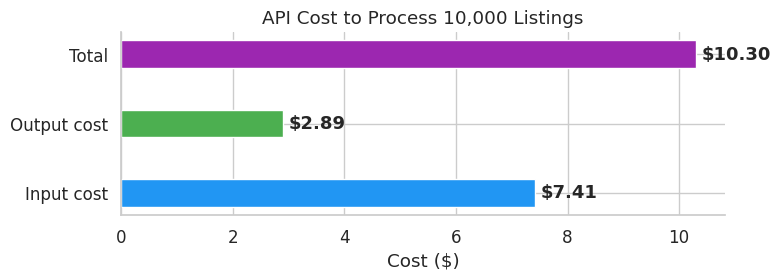

In [41]:
# Simple chart to show these costs
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(['Input cost', 'Output cost', 'Total'],
               [input_cost, output_cost, total_api_cost],
               color=['#2196F3', '#4CAF50', '#9C27B0'], height=0.4, edgecolor='white')
for b, a in zip(bars, [input_cost, output_cost, total_api_cost]):
    ax.text(b.get_width() + 0.1, b.get_y() + b.get_height()/2,
            f'${a:.2f}', va='center', fontsize=13, fontweight='bold')
ax.set_xlabel('Cost ($)')
ax.set_title('API Cost to Process 10,000 Listings')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### How much does cleaning save?

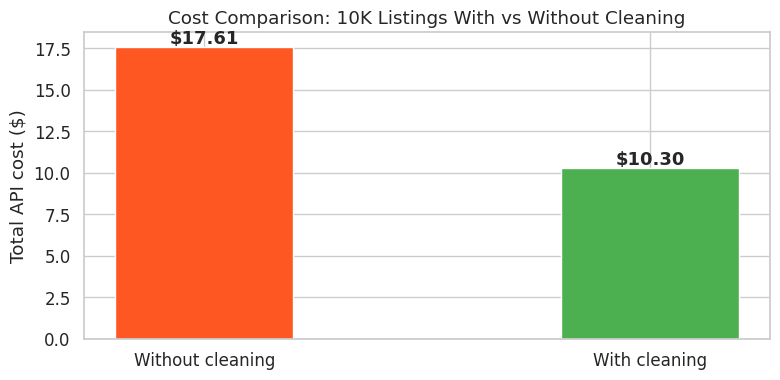

Without cleaning: $17.61 (sending ALL raw reviews)
With cleaning:    $10.30 (capped at 15, junk removed)
Saved:            $7.30 (41%)


In [42]:
# What would 10K listings cost WITHOUT cleaning?
raw_tokens_per_listing = reviews_raw.groupby('listing_id')['comment_length'].sum().mean() / 4
clean_tokens_per_listing = reviews_clean.assign(
    cl=reviews_clean['comments_clean'].str.len()
).groupby('listing_id')['cl'].sum().mean() / 4

raw_total_cost = (raw_tokens_per_listing * N / 1e6 * INPUT_PRICE) + (avg_out * N / 1e6 * OUTPUT_PRICE)
clean_total_cost = total_api_cost  # already calculated above

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Without cleaning', 'With cleaning'], [raw_total_cost, clean_total_cost],
              color=['#FF5722', '#4CAF50'], width=0.4, edgecolor='white')
ax.set_ylabel('Total API cost ($)')
ax.set_title('Cost Comparison: 10K Listings With vs Without Cleaning')
for b, v in zip(bars, [raw_total_cost, clean_total_cost]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
            f'${v:.2f}', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

saved = raw_total_cost - clean_total_cost
print(f"Without cleaning: ${raw_total_cost:.2f} (sending ALL raw reviews)")
print(f"With cleaning:    ${clean_total_cost:.2f} (capped at {MAX_REVIEWS_PER_LISTING}, junk removed)")
print(f"Saved:            ${saved:.2f} ({saved/raw_total_cost:.0%})")

**Component 3 summary:** Cross-validation against Airbnb's actual scores shows 92-100% accuracy per dimension. The pipeline is reliable on positive signals but untested on truly negative properties. At 10,000 listings, total API cost is ~\$10 with cleaning vs ~\$18 without (a 41% saving). I validated against real ground truth rather than self-consistency because a model agreeing with itself doesn't prove it's correct.

### Patterns and limitations

A few things I noticed in the results:

In [43]:
sentiments = Counter(r['profile'].get('overall_sentiment') for r in successful)
all_positive = sum(1 for r in successful
    if all(r['profile'].get(f,{}).get('signal') == 'positive'
           for f in ['cleanliness','location_quality','host_communication','check_in_experience','value_perception']))
no_guest_fit = sum(1 for r in successful if not r['profile'].get('best_guest_fit'))

print(f"Sentiment distribution: {dict(sentiments)}")
print(f"Every dimension positive: {all_positive}/{len(successful)} ({all_positive/len(successful):.0%})")
print(f"No guest fit identified: {no_guest_fit}/{len(successful)}")

Sentiment distribution: {'positive': 24, 'mixed': 6}
Every dimension positive: 15/30 (50%)
No guest fit identified: 0/30


**Why so many "positive"?** 24 out of 30 listings came back positive. This reflects Airbnb reviews in general — guests who had a bad experience often just leave a low star rating without writing a detailed review. Still, we got 6 "mixed" results, which shows the model can pick up on problems when they're in the reviews.

**50% had every dimension positive.** The other 50% had at least one dimension that wasn't positive — meaning the model is picking up nuance, not just defaulting to "everything is great."

**Guest fit worked well.** The model identified a guest fit for all 30 listings, which means it's reading context clues (mentions of kids, couples, business trips, etc.) effectively.

**Limitation:** No listing received an overall "negative" sentiment — only "positive" (24) or "mixed" (6). The model does flag negative signals on individual dimensions (e.g. cleanliness or communication), but never judged an entire property as negative overall. Before production use, a second test targeting low-rated properties would confirm the pipeline can identify genuinely problematic listings end-to-end.

### Manual spot-check

A few profiles alongside the actual source reviews, to eyeball whether the extraction makes sense:

In [46]:
for r in successful[:2]:
    lid = r['listing_id']
    group = grouped.get_group(lid)
    p = r['profile']

    print(f"{'='*70}")
    print(f"LISTING {lid} — {r['n_reviews']} reviews")
    print(f"{'='*70}")
    print("\nSource reviews (first 5):")
    for i, (_, row) in enumerate(group.head(5).iterrows()):
        print(f"  [{i+1}] {row['comments_clean'][:500]}...")
    print(f"\nExtracted profile:")
    print(f"  Sentiment:  {p.get('overall_sentiment')} | Confidence: {p.get('confidence')}")
    print(f"  Praises:    {p.get('top_praises', [])}")
    print(f"  Complaints: {p.get('top_complaints', [])}")
    print(f"  Noise: {p.get('noise_level')} | Guest fit: {p.get('best_guest_fit', [])}")
    print()

LISTING 763419 — 13 reviews

Source reviews (first 5):
  [1] Buen lugar para ir con niños, muy accesible...
  [2] Our stay at Aline's place was very pleasant. Aline was flexible for the check-in time and made sure everything run well. The Appartement was exactly like described and shown in the photos. It was clean and neat! I highly recommend the place! The only critic that I could mention is concerning the wifi. It is a 4G router with very limited data volume. So it could only be used for small stuff and not for streaming for example....
  [3] Nice place. Friendly host. Good location....
  [4] Superbly nice and comfortable place. Great neighborhood (with a convenient grocery store just down the street). The terrace is perfect for coffee in the mornings and dinners in the evenings. Simply wonderful Paris experience!...
  [5] J'ai passé 10 jours chez Aline et Mathieu. Tout s'est bien passé Mathieu m'a très bien accueilli. Il y a un Franprix juste à coté de l'appartement et le métro est 

### Human review recommendations

For 10,000 listings, I'd recommend reviewing about 15-20% of profiles manually:
- All profiles where the model reported "low" confidence
- All profiles with "negative" overall sentiment (high stakes — you don't want to miss a real problem or flag a good property incorrectly)
- A random 5% of "positive" profiles to stay calibrated

At ~2-3 minutes per review, that's roughly 50-100 hours of human time. The **AI handles the volume; humans handle the judgment calls.**

---

## Summary for the Portfolio Manager

### What I built

A system that reads guest reviews for a property listing and produces a one-page scorecard: cleanliness, location, noise, host quality, value, what types of guests it suits, and the most common praises and complaints.

### Does it work?

**Yes.** I checked the results against Airbnb's own guest ratings and got **~92-100% accuracy** across cleanliness, location, communication, and value. All profiles were internally consistent — no contradictions. It handles French, English and other languages reviews without needing translation.

### Where it needs caution

- Properties with very few reviews get less reliable profiles because the data is less — these should be reviewed/cross checked by a person manually.
- Most properties in our test came back "positive" (Airbnb reviews skew positive). Before trusting this for real decisions, I'd recommend a second test specifically on low-rated properties to see if we get "negative" profiles as well.

### What would it cost with this pipeline?

For all 10,000 Paris properties:
- **Total AI cost:** About \$10 - \$15 total (Genuinely cheap)
- **Total Avg time (with 5 parallel workers):** ~1 hour using paid tier LLM

### Recommendations

1. **Start with problematic properties** — the ones with low ratings (negative or neutral) or lots of complaints. That's where the insights are most valuable.
2. **Look at neighborhoods** - some neighborhood has mixed/negative sentiments. These are worth investigating first to decide if those properties are worth keeping or need improvement.
3. **Run quarterly** to track whether renovations, new hosts, or pricing changes are showing up in guest feedback.
4. **Don't skip human review.** The AI is the cheap and easy part. The value is in property managers acting on what it finds.

## What I'd do next with more time

1. **Token budget instead of review count cap** — Instead of "keep 15 most recent reviews," use "keep adding reviews until you hit 4,000 tokens." This approach can be smarter because short reviews would allow more to fit, while long ones use fewer slots.

2. **Topic modeling before LLM** — Use BERTopic to group reviews by topic ("15 mention noise, 8 mention cleanliness"), then send the summary instead of raw text. Cheaper and more accurate.

3. **Batch processing for cost savings** — Process requests in bulk at off-peak hours for lower rates.

4. **Track changes over time** — "Cleanliness was positive in 2023 but negative in 2024" is more useful than a single snapshot.

5. **Cache results** — Reviews don't change after posting. Only re-process a listing when new reviews appear.

6. **Test on problem properties** — Our sample was mostly positive. A targeted test on low-rated listings would validate the pipeline for the cases that matter most.

7. **Second LLM as judge** - Use another LLM as a judge to evaluate the reasoning LLMs output. This can reduce hallucinations.